# Phase 2 Random Forest Model

This notebook trains the first phase-2 model: a Random Forest predicting next-year median sale price from the selected feature set. It uses the prepared train/test split:

- Train/CV pool: 2012-2022 rows
- Final holdout: 2023 rows, targeting 2024 median sale price
- Target used for training: `log(next_year_annual_median_sale_price)`

The notebook writes metrics, predictions, and feature-importance files to `outputs/phase2-models/random-forest/`.

In [1]:
from pathlib import Path
import json
import os

PROJECT_ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / 'outputs' / 'phase2-models' / 'model-data').exists()
)

CACHE_DIR = PROJECT_ROOT / 'outputs' / 'cache'
os.environ.setdefault('MPLCONFIGDIR', str(CACHE_DIR / 'matplotlib'))
os.environ.setdefault('XDG_CACHE_HOME', str(CACHE_DIR / 'xdg'))
(CACHE_DIR / 'matplotlib').mkdir(parents=True, exist_ok=True)
(CACHE_DIR / 'xdg').mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

RANDOM_STATE = 42
MODEL_DATA_DIR = PROJECT_ROOT / 'outputs' / 'phase2-models' / 'model-data'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'phase2-models' / 'random-forest'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 120)

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'OUTPUT_DIR: {OUTPUT_DIR}')

PROJECT_ROOT: /Users/charlesgao/Desktop/spring2026/stats170B/project
OUTPUT_DIR: /Users/charlesgao/Desktop/spring2026/stats170B/project/outputs/phase2-models/random-forest


## Load Selected Model Data

In [2]:
train = pd.read_csv(MODEL_DATA_DIR / 'phase2_selected_train_2012_2022.csv', dtype={'zcta5': str}, low_memory=False)
test = pd.read_csv(MODEL_DATA_DIR / 'phase2_selected_test_2023.csv', dtype={'zcta5': str}, low_memory=False)
feature_schema = pd.read_csv(MODEL_DATA_DIR / 'phase2_selected_feature_schema.csv')
feature_config = json.loads((MODEL_DATA_DIR / 'phase2_selected_features.json').read_text())
cv_folds = pd.read_csv(MODEL_DATA_DIR / 'phase2_time_blocked_cv_folds.csv')

TARGET = 'y_log_next_year_median_sale_price'
TARGET_DOLLARS = 'y_next_year_median_sale_price'
FEATURES = feature_config['feature_sets']['all_selected_features']
NUMERIC_FEATURES = feature_config['preprocessing']['numeric']
CATEGORICAL_FEATURES = feature_config['preprocessing']['categorical']
BOOLEAN_FEATURES = feature_config['preprocessing']['boolean']

print(f'Train shape: {train.shape}')
print(f'Test shape: {test.shape}')
print(f'Selected features: {len(FEATURES)}')
print(f'Numeric: {len(NUMERIC_FEATURES)}, categorical: {len(CATEGORICAL_FEATURES)}, boolean: {len(BOOLEAN_FEATURES)}')
print(f'Train years: {train.year.min()}-{train.year.max()}')
print(f'Test years: {sorted(test.year.unique())}')

Train shape: (12530, 59)
Test shape: (1138, 59)
Selected features: 54
Numeric: 44, categorical: 3, boolean: 7
Train years: 2012-2022
Test years: [np.int64(2023)]


## Preprocessing And Model Definition

In [3]:
RF_PARAMS = {
    'n_estimators': 500,
    'max_depth': None,
    'min_samples_leaf': 3,
    'max_features': 'sqrt',
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
}

def make_preprocessor() -> ColumnTransformer:
    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
    ])
    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    boolean_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    return ColumnTransformer(
        transformers=[
            ('numeric', numeric_pipeline, NUMERIC_FEATURES),
            ('categorical', categorical_pipeline, CATEGORICAL_FEATURES),
            ('boolean', boolean_pipeline, BOOLEAN_FEATURES),
        ],
        remainder='drop',
        verbose_feature_names_out=True,
    )

def make_random_forest_pipeline() -> Pipeline:
    return Pipeline([
        ('preprocess', make_preprocessor()),
        ('model', RandomForestRegressor(**RF_PARAMS)),
    ])

def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def evaluate_predictions(y_true_log, y_pred_log) -> dict[str, float]:
    y_true_dollars = np.exp(y_true_log)
    y_pred_dollars = np.exp(y_pred_log)
    return {
        'mae_log': mean_absolute_error(y_true_log, y_pred_log),
        'rmse_log': rmse(y_true_log, y_pred_log),
        'r2_log': r2_score(y_true_log, y_pred_log),
        'mae_dollars': mean_absolute_error(y_true_dollars, y_pred_dollars),
        'rmse_dollars': rmse(y_true_dollars, y_pred_dollars),
        'r2_dollars': r2_score(y_true_dollars, y_pred_dollars),
    }

def feature_group_lookup() -> dict[str, str]:
    selected = feature_schema[feature_schema['selected']].copy()
    return dict(zip(selected['feature'], selected['source_group']))

## Time-Blocked Cross Validation

Each fold trains on past years and validates on the next held-out year.

In [4]:
cv_rows = []

for fold in cv_folds.itertuples(index=False):
    train_fold = train[train['year'].lt(fold.validation_year)].copy()
    validation_fold = train[train['year'].eq(fold.validation_year)].copy()

    model = make_random_forest_pipeline()
    model.fit(train_fold[FEATURES], train_fold[TARGET])
    pred_log = model.predict(validation_fold[FEATURES])
    metrics = evaluate_predictions(validation_fold[TARGET], pred_log)
    metrics.update({
        'fold': fold.fold,
        'validation_year': fold.validation_year,
        'train_rows': len(train_fold),
        'validation_rows': len(validation_fold),
    })
    cv_rows.append(metrics)

cv_metrics = pd.DataFrame(cv_rows)
metric_cols = ['fold', 'validation_year', 'train_rows', 'validation_rows', 'mae_dollars', 'rmse_dollars', 'r2_dollars', 'mae_log', 'rmse_log', 'r2_log']
cv_metrics = cv_metrics[metric_cols]
cv_metrics.to_csv(OUTPUT_DIR / 'random_forest_cv_metrics.csv', index=False)
cv_metrics

,fold,validation_year,train_rows,validation_rows,mae_dollars,rmse_dollars,r2_dollars,mae_log,rmse_log,r2_log
0,1,2017,5590,1146,70234.006647,189653.617793,0.870885,0.086303,0.128508,0.961056
1,2,2018,6736,1155,55813.267661,144776.286246,0.922142,0.074933,0.117072,0.966523
2,3,2019,7891,1159,75332.751696,164659.446429,0.904070,0.093551,0.131367,0.955017
3,4,2020,9050,1178,146360.495721,282778.692932,0.794197,0.157739,0.194478,0.896136
4,5,2021,10228,1160,113350.011631,253978.898162,0.841097,0.103237,0.148373,0.939562
5,6,2022,11388,1142,96997.963837,224181.214518,0.873430,0.102907,0.140618,0.943160


In [5]:
cv_summary = cv_metrics.drop(columns=['fold', 'validation_year']).agg(['mean', 'std']).T.reset_index()
cv_summary = cv_summary.rename(columns={'index': 'metric'})
cv_summary.to_csv(OUTPUT_DIR / 'random_forest_cv_summary.csv', index=False)
cv_summary

,metric,mean,std
0,train_rows,8480.500000,2171.516682
1,validation_rows,1156.666667,12.675436
2,mae_dollars,93014.749532,33138.265086
3,rmse_dollars,210004.692680,53208.762896
4,r2_dollars,0.867637,0.045695
5,mae_log,0.103112,0.028817
6,rmse_log,0.143403,0.027207
7,r2_log,0.943576,0.025416


## Final Train On 2012-2022, Test On 2023

In [6]:
final_model = make_random_forest_pipeline()
final_model.fit(train[FEATURES], train[TARGET])

test_pred_log = final_model.predict(test[FEATURES])
test_metrics = evaluate_predictions(test[TARGET], test_pred_log)
test_metrics = pd.DataFrame([{**test_metrics, 'train_years': '2012-2022', 'test_year': 2023, 'target_year': 2024}])
test_metrics.to_csv(OUTPUT_DIR / 'random_forest_2023_holdout_metrics.csv', index=False)
test_metrics

,mae_log,rmse_log,r2_log,mae_dollars,rmse_dollars,r2_dollars,train_years,test_year,target_year
0,0.095282,0.137366,0.948524,103232.647502,245971.668099,0.873647,2012-2022,2023,2024


In [7]:
holdout_predictions = test[['zcta5', 'year', TARGET_DOLLARS, TARGET]].copy()
holdout_predictions['pred_log_next_year_median_sale_price'] = test_pred_log
holdout_predictions['pred_next_year_median_sale_price'] = np.exp(test_pred_log)
holdout_predictions['absolute_error_dollars'] = (
    holdout_predictions['pred_next_year_median_sale_price'] - holdout_predictions[TARGET_DOLLARS]
).abs()
holdout_predictions['error_dollars'] = (
    holdout_predictions['pred_next_year_median_sale_price'] - holdout_predictions[TARGET_DOLLARS]
)
holdout_predictions.to_csv(OUTPUT_DIR / 'random_forest_2023_holdout_predictions.csv', index=False)
holdout_predictions.sort_values('absolute_error_dollars', ascending=False).head(20)

,zcta5,year,y_next_year_median_sale_price,y_log_next_year_median_sale_price,pred_log_next_year_median_sale_price,pred_next_year_median_sale_price,absolute_error_dollars,error_dollars
691,94027,2023,7.610922e+06,15.845095,15.179503,3.911780e+06,3.699142e+06,-3.699142e+06
460,92657,2023,5.791146e+06,15.571841,15.022019,3.341797e+06,2.449350e+06,-2.449350e+06
462,92662,2023,4.517883e+06,15.323554,14.695727,2.411422e+06,2.106462e+06,-2.106462e+06
461,92661,2023,4.429966e+06,15.303903,14.675962,2.364228e+06,2.065738e+06,-2.065738e+06
289,92067,2023,5.068633e+06,15.438582,14.945622,3.096003e+06,1.972630e+06,-1.972630e+06
529,93108,2023,5.319681e+06,15.486924,15.046540,3.424753e+06,1.894928e+06,-1.894928e+06
692,94028,2023,4.324725e+06,15.279859,14.744915,2.532999e+06,1.791726e+06,-1.791726e+06
845,94970,2023,3.788393e+06,15.147452,14.508122,1.998930e+06,1.789463e+06,-1.789463e+06
55,90210,2023,4.225989e+06,15.256764,14.906514,2.977259e+06,1.248730e+06,-1.248730e+06
731,94305,2023,3.103385e+06,14.948004,14.482075,1.947535e+06,1.155850e+06,-1.155850e+06


## One Example Tree From The Forest

A Random Forest averages predictions across many decision trees. For presentation, this plots only the top three levels of one tree so the split logic is readable.

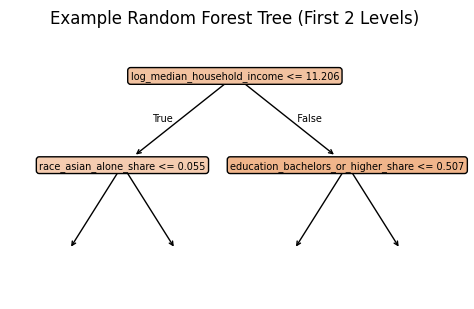

In [23]:
from sklearn.tree import plot_tree

example_tree = final_model.named_steps['model'].estimators_[0]
transformed_feature_names = final_model.named_steps['preprocess'].get_feature_names_out()
display_feature_names = [
    name.replace('numeric__', '').replace('categorical__', '').replace('boolean__', '')
    for name in transformed_feature_names
]

fig, ax = plt.subplots(figsize=(5, 3.2))
tree_artists = plot_tree(
    example_tree,
    feature_names=display_feature_names,
    max_depth=1,
    filled=True,
    rounded=True,
    fontsize=7,
    impurity=False,
    ax=ax,
)

# Keep only the split rule in each node; hide samples/value text for slide readability.
for artist in tree_artists:
    lines = artist.get_text().split('\n')
    split_lines = [line for line in lines if '<=' in line or line == '(...)']
    artist.set_text(split_lines[0] if split_lines else lines[0])

ax.set_title('Example Random Forest Tree (First 2 Levels)')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'random_forest_example_tree_depth1.png', dpi=200, bbox_inches='tight')
plt.show()

## Built-In Random Forest Feature Importance

This is impurity-based importance after preprocessing. It is useful as a first pass, but it can favor continuous or high-cardinality features. The permutation importance section below is the more defensible importance view.

In [9]:
transformed_feature_names = final_model.named_steps['preprocess'].get_feature_names_out()
impurity_importance = pd.DataFrame({
    'transformed_feature': transformed_feature_names,
    'importance': final_model.named_steps['model'].feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)

def original_feature_from_transformed(transformed_name: str) -> str:
    _, raw_name = transformed_name.split('__', 1)
    for feature in sorted(FEATURES, key=len, reverse=True):
        if raw_name == feature or raw_name.startswith(f'{feature}_'):
            return feature
    return raw_name

group_lookup = feature_group_lookup()
impurity_importance['feature'] = impurity_importance['transformed_feature'].map(original_feature_from_transformed)
impurity_importance['source_group'] = impurity_importance['feature'].map(group_lookup).fillna('unknown')
impurity_importance.to_csv(OUTPUT_DIR / 'random_forest_impurity_importance_transformed.csv', index=False)

impurity_feature_importance = (
    impurity_importance.groupby(['feature', 'source_group'], as_index=False)['importance']
    .sum()
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)
impurity_feature_importance.to_csv(OUTPUT_DIR / 'random_forest_impurity_importance_features.csv', index=False)
impurity_feature_importance.head(25)

,feature,source_group,importance
0,annual_median_sale_price,listings,0.243083
1,annual_median_ppsf,listings,0.177232
2,born_other_state_25plus_bachelors_or_higher_share,demographics,0.082221
3,education_bachelors_or_higher_share,demographics,0.078654
4,log_median_household_income,demographics,0.072210
5,foreign_born_25plus_bachelors_or_higher_share,demographics,0.043661
6,education_some_college_or_associates_share,demographics,0.023635
7,education_less_than_high_school_share,demographics,0.022880
8,avg_pct_met_overall_z_assessment_year,school_quality,0.019674
9,age_0_17_share,demographics,0.017773


## Permutation Feature Importance On 2023 Holdout

This measures how much holdout performance worsens when each raw feature is shuffled. Higher values mean the feature contributed more to the final model's 2023 predictions.

In [10]:
permutation = permutation_importance(
    final_model,
    test[FEATURES],
    test[TARGET],
    scoring='neg_mean_absolute_error',
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

permutation_importance_df = pd.DataFrame({
    'feature': FEATURES,
    'importance_mean_log_mae': permutation.importances_mean,
    'importance_std_log_mae': permutation.importances_std,
})
permutation_importance_df['source_group'] = permutation_importance_df['feature'].map(group_lookup).fillna('unknown')
permutation_importance_df = permutation_importance_df.sort_values('importance_mean_log_mae', ascending=False).reset_index(drop=True)
permutation_importance_df.to_csv(OUTPUT_DIR / 'random_forest_permutation_importance.csv', index=False)
permutation_importance_df.head(25)

,feature,importance_mean_log_mae,importance_std_log_mae,source_group
0,annual_median_sale_price,0.168603,0.001885,listings
1,annual_median_ppsf,0.084684,0.000406,listings
2,log_median_household_income,0.021953,0.000624,demographics
3,born_other_state_25plus_bachelors_or_higher_share,0.021638,0.000845,demographics
4,education_bachelors_or_higher_share,0.021538,0.000673,demographics
5,education_some_college_or_associates_share,0.009217,0.000362,demographics
6,foreign_born_25plus_bachelors_or_higher_share,0.006420,0.000377,demographics
7,parent_metro_region,0.004881,0.000213,listings
8,education_less_than_high_school_share,0.003765,0.000293,demographics
9,annual_avg_sale_to_list,0.003270,0.000322,listings


In [11]:
group_permutation_importance = (
    permutation_importance_df.groupby('source_group', as_index=False)
    .agg(
        importance_sum_log_mae=('importance_mean_log_mae', 'sum'),
        importance_mean_log_mae=('importance_mean_log_mae', 'mean'),
        features=('feature', 'count'),
    )
    .sort_values('importance_sum_log_mae', ascending=False)
    .reset_index(drop=True)
)
group_permutation_importance.to_csv(OUTPUT_DIR / 'random_forest_permutation_importance_by_group.csv', index=False)
group_permutation_importance

,source_group,importance_sum_log_mae,importance_mean_log_mae,features
0,listings,0.268577,0.022381,12
1,demographics,0.107845,0.004314,25
2,amenities,0.003768,0.000754,5
3,school_quality,0.003590,0.000598,6
4,other,0.002728,0.002728,1
5,crime,0.001594,0.000797,2
6,minimum_wage,0.000149,0.000050,3


## Quick Visuals

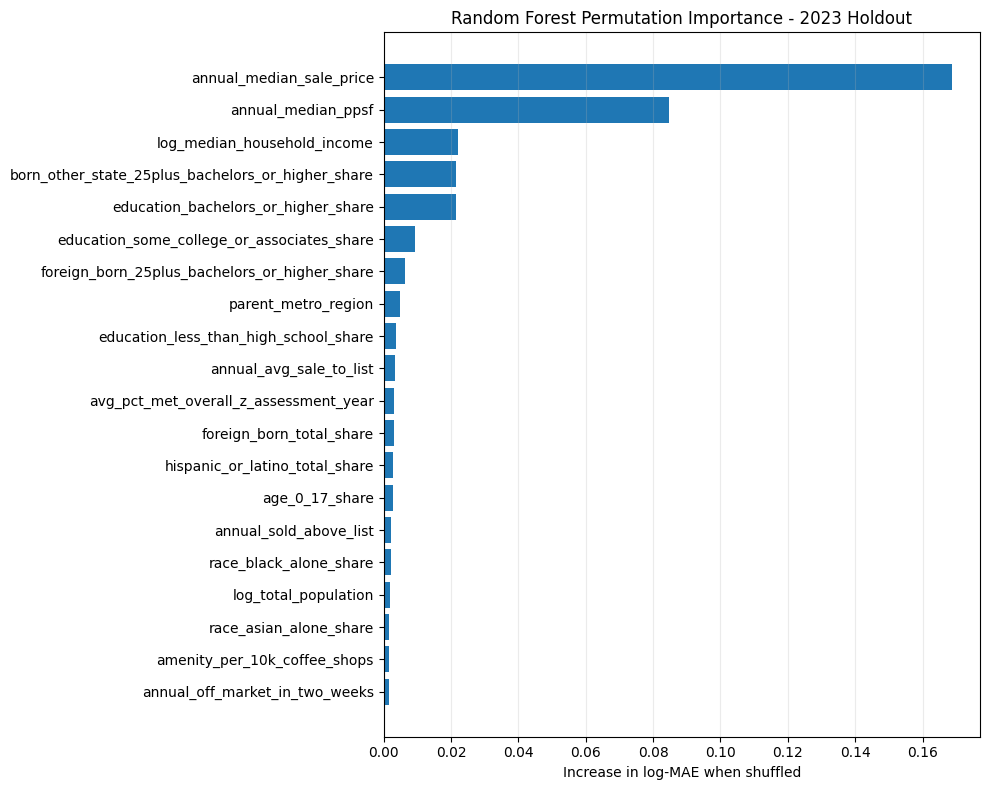

In [12]:
top_n = 20
plot_df = permutation_importance_df.head(top_n).iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(plot_df['feature'], plot_df['importance_mean_log_mae'])
ax.set_title('Random Forest Permutation Importance - 2023 Holdout')
ax.set_xlabel('Increase in log-MAE when shuffled')
ax.grid(axis='x', alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'random_forest_top20_permutation_importance.png', dpi=200)
plt.show()

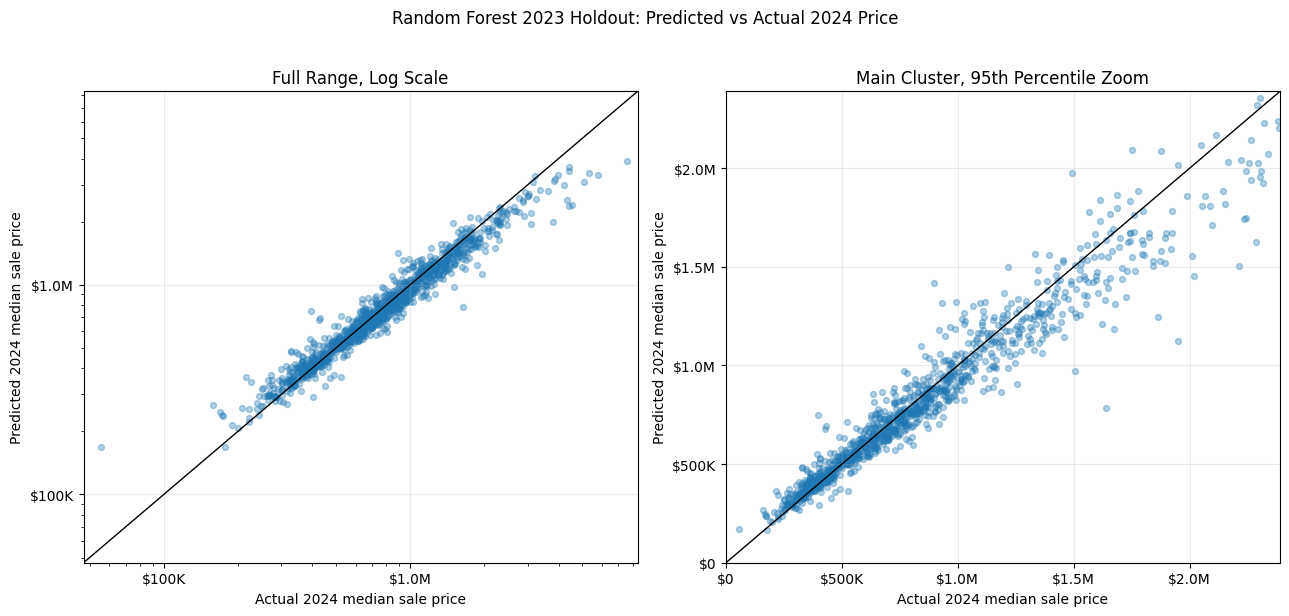

In [13]:
from matplotlib.ticker import FuncFormatter

actual_price = holdout_predictions[TARGET_DOLLARS]
predicted_price = holdout_predictions['pred_next_year_median_sale_price']

def compact_dollars(value, _):
    if value >= 1_000_000:
        return f'${value / 1_000_000:.1f}M'
    if value >= 1_000:
        return f'${value / 1_000:.0f}K'
    return f'${value:.0f}'

dollar_formatter = FuncFormatter(compact_dollars)
positive_mask = actual_price.gt(0) & predicted_price.gt(0)
full_lims = [
    min(actual_price[positive_mask].min(), predicted_price[positive_mask].min()) * 0.85,
    max(actual_price[positive_mask].max(), predicted_price[positive_mask].max()) * 1.10,
]
zoom_limit = max(actual_price.quantile(0.95), predicted_price.quantile(0.95)) * 1.10

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

axes[0].scatter(actual_price, predicted_price, alpha=0.35, s=18)
axes[0].plot(full_lims, full_lims, color='black', linewidth=1)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlim(full_lims)
axes[0].set_ylim(full_lims)
axes[0].set_title('Full Range, Log Scale')

axes[1].scatter(actual_price, predicted_price, alpha=0.35, s=18)
axes[1].plot([0, zoom_limit], [0, zoom_limit], color='black', linewidth=1)
axes[1].set_xlim(0, zoom_limit)
axes[1].set_ylim(0, zoom_limit)
axes[1].set_title('Main Cluster, 95th Percentile Zoom')

for ax in axes:
    ax.set_xlabel('Actual 2024 median sale price')
    ax.set_ylabel('Predicted 2024 median sale price')
    ax.xaxis.set_major_formatter(dollar_formatter)
    ax.yaxis.set_major_formatter(dollar_formatter)
    ax.grid(alpha=0.25)

fig.suptitle('Random Forest 2023 Holdout: Predicted vs Actual 2024 Price', y=1.02)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'random_forest_2023_predicted_vs_actual.png', dpi=200, bbox_inches='tight')
plt.show()

## Output Files

After running all cells, the key files are:

- `random_forest_cv_metrics.csv`
- `random_forest_cv_summary.csv`
- `random_forest_2023_holdout_metrics.csv`
- `random_forest_2023_holdout_predictions.csv`
- `random_forest_example_tree_depth1.png`
- `random_forest_impurity_importance_features.csv`
- `random_forest_permutation_importance.csv`
- `random_forest_permutation_importance_by_group.csv`
- `random_forest_top20_permutation_importance.png`
- `random_forest_2023_predicted_vs_actual.png`